In [15]:
import pooch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POOCH = pooch.create(
    path=pooch.os_cache('noaa-data'),
    base_url='doi:10.5281/zenodo.5553029/',
    registry={
        'HEADERS.txt': 'md5:2a306ca225fe3ccb72a98953ded2f536',
        'CRND0103-2016-NY_Millbrook_3_W.txt': 'md5:eb69811d14d0573ffa69f70dd9c768d9',
        'CRND0103-2017-NY_Millbrook_3_W.txt': 'md5:b911da727ba1bdf26a34a775f25d1088',
        'CRND0103-2018-NY_Millbrook_3_W.txt': 'md5:5b61bc687261596eba83801d7080dc56',
        'CRND0103-2019-NY_Millbrook_3_W.txt': 'md5:9b814430612cd8a770b72020ca4f2b7d',
        'CRND0103-2020-NY_Millbrook_3_W.txt': 'md5:cd8de6d5445024ce35fcaafa9b0e7b64'
    },
)

with open(POOCH.fetch('HEADERS.txt')) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')

# ✅ These are the numpy arrays we'll use for plotting
t_daily_min       = df.T_DAILY_MIN.values
t_daily_max       = df.T_DAILY_MAX.values
t_daily_mean      = df.T_DAILY_MEAN.values
p_daily_calc      = df.P_DAILY_CALC.values
soil_moisture_5   = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10  = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20  = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50  = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date              = df.index.values

print('Data loaded! Arrays ready.')

Data loaded! Arrays ready.


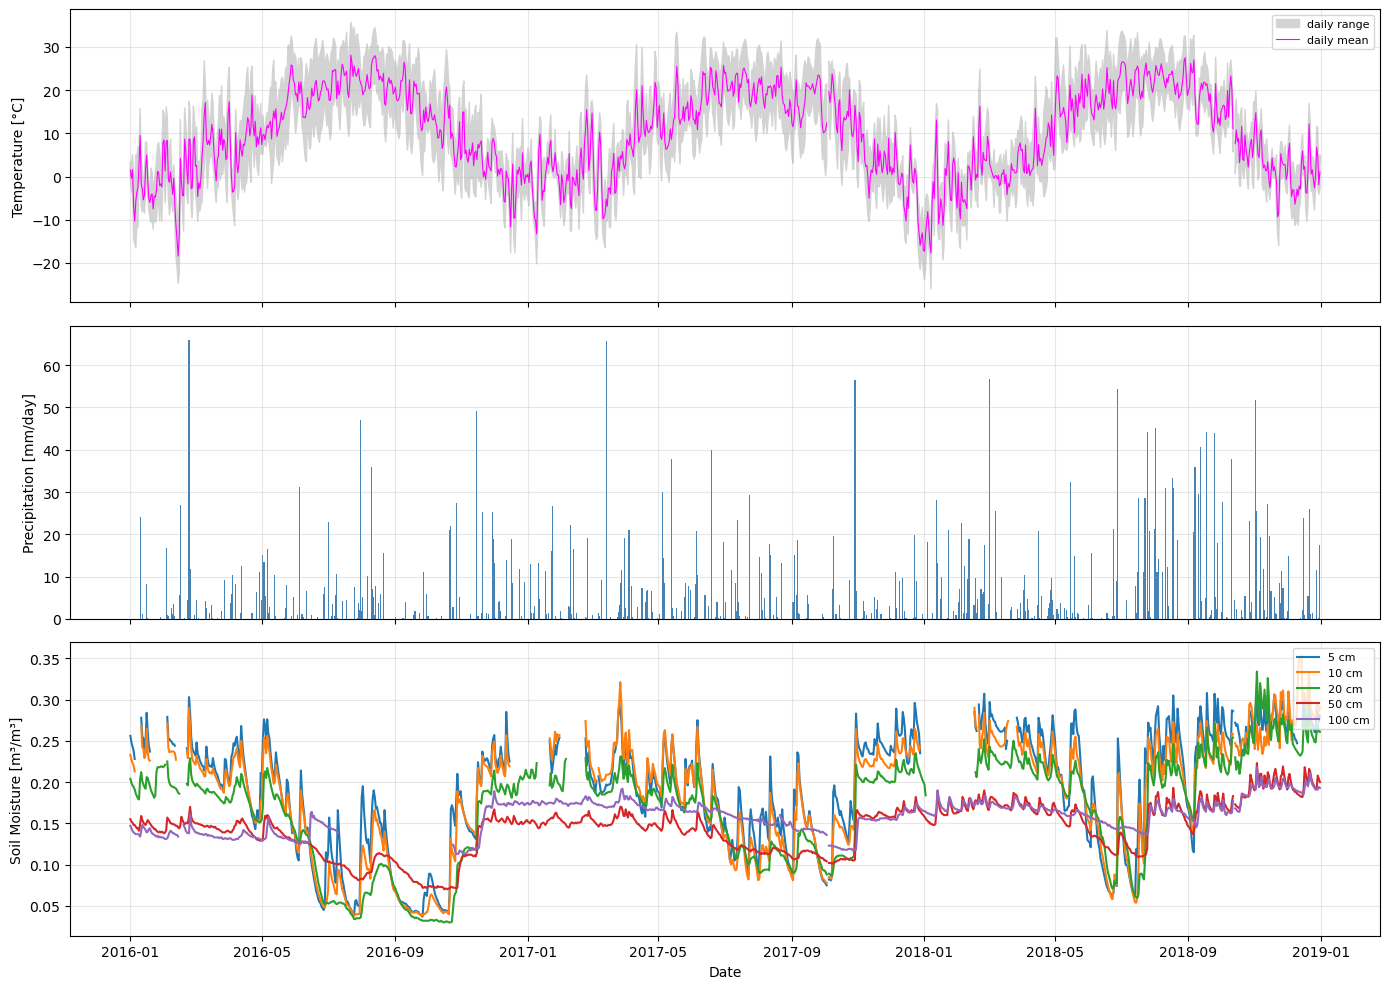

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ── Panel 1: Temperature ──────────────────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(date, t_daily_min, t_daily_max, color='lightgray', label='daily range')
ax1.plot(date, t_daily_mean, color='magenta', linewidth=0.8, label='daily mean')
ax1.set_ylabel('Temperature [°C]')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Precipitation ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.bar(date, p_daily_calc, color='steelblue', width=1.0)
ax2.set_ylabel('Precipitation [mm/day]')
ax2.grid(True, alpha=0.3)

# ── Panel 3: Soil Moisture ────────────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(date, soil_moisture_5,   label='5 cm')
ax3.plot(date, soil_moisture_10,  label='10 cm')
ax3.plot(date, soil_moisture_20,  label='20 cm')
ax3.plot(date, soil_moisture_50,  label='50 cm')
ax3.plot(date, soil_moisture_100, label='100 cm')
ax3.set_ylabel('Soil Moisture [m³/m³]')
ax3.set_xlabel('Date')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [25]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

Note:Caching=1


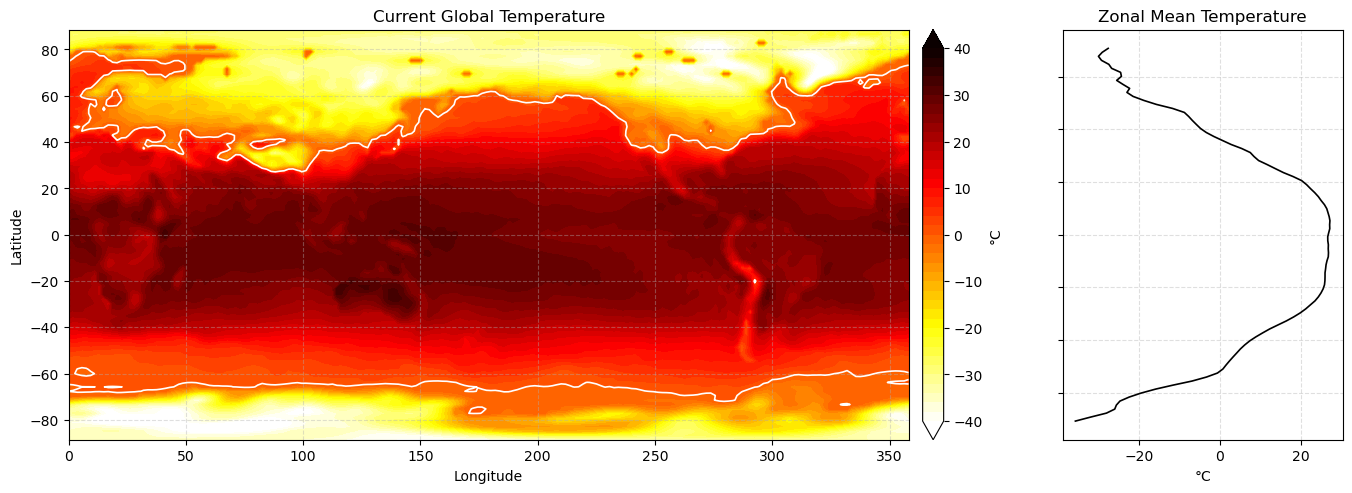

In [26]:
fig = plt.figure(figsize=(14, 5))

# Left panel: filled contour map 
ax_map = fig.add_axes([0.05, 0.1, 0.60, 0.82])

levels = np.linspace(-40, 40, 41)
cf = ax_map.contourf(lon, lat, temp, levels=levels, cmap='hot_r', extend='both')

# white contour line at 0°C
ax_map.contour(lon, lat, temp, levels=[0], colors='white', linewidths=1.2)

ax_map.set_xlabel('Longitude')
ax_map.set_ylabel('Latitude')
ax_map.set_title('Current Global Temperature')
ax_map.grid(True, linestyle='--', alpha=0.4)

# ── Colorbar ──
cbar_ax = fig.add_axes([0.66, 0.1, 0.015, 0.82])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label('°C')

# ── Right panel: zonal mean 
ax_zone = fig.add_axes([0.76, 0.1, 0.20, 0.82])

zonal_mean = np.nanmean(temp, axis=1)  # average over all longitudes
ax_zone.plot(zonal_mean, lat, color='black', linewidth=1.2)
ax_zone.set_xlabel('°C')
ax_zone.set_title('Zonal Mean Temperature')
ax_zone.grid(True, linestyle='--', alpha=0.4)
ax_zone.tick_params(labelleft=False)

plt.show()

In [27]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/db3812/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/db3812/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


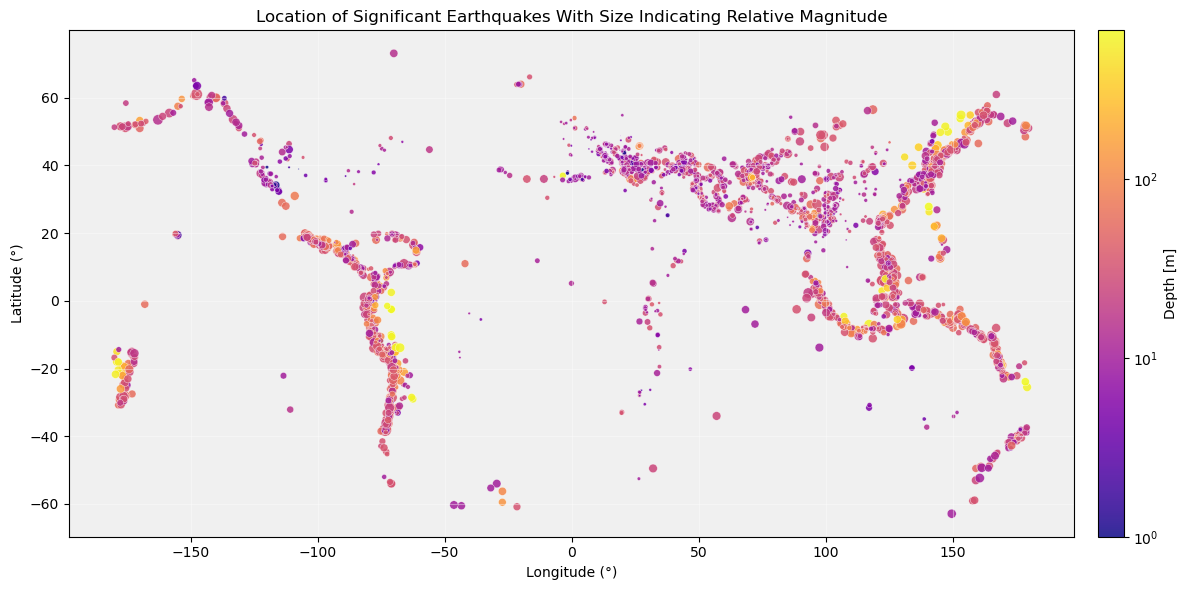

In [29]:
mask = (np.isfinite(depth) & np.isfinite(magnitude) &
        np.isfinite(latitude) & np.isfinite(longitude) & (depth > 0))

depth_c = depth[mask]
mag_c   = magnitude[mask]
lat_c   = latitude[mask]
lon_c   = longitude[mask]

log_depth   = np.log10(depth_c)
marker_size = mag_c**4 / 100

fig, ax = plt.subplots(figsize=(13, 6))

sc = ax.scatter(lon_c, lat_c,
                c=log_depth,
                s=marker_size,
                cmap='plasma',        # changed from viridis
                alpha=0.85,           # slightly more opaque
                linewidths=0.3,       # subtle edge
                edgecolors='white')   # white outline on dots

ax.set_facecolor('#f0f0f0')           # light gray background
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax.grid(True, alpha=0.4, color='white')

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Depth [m]')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['$10^0$', '$10^1$', '$10^2$'])

plt.tight_layout()
plt.show()

In [30]:
git remote add origin git@github.com:db3812-del/Assignment_3-10-26.git
git branch -M main
git push -u origin main

SyntaxError: invalid decimal literal (2887931828.py, line 1)